# Data understanding and preprocessing

Initial data understanding and preprocessing checks for the accelerometer recordings. The workflow follows the inspection methods in `course_files/practical/preprocessing/instruction_3.ipynb` and the sampling concepts from the September 4 lecture.

## 1. Setup

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start_path):
    start_path = Path(start_path).resolve()
    search_paths = (start_path, *start_path.parents)
    for path in search_paths:
        data_root = path / "data" / "recordings" / "raw"
        if data_root.is_dir():
            return path
    raise FileNotFoundError(
        "Could not find data/recordings/raw. Run this notebook from the "
        "repository root or one of its subdirectories."
    )

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "data" / "recordings" / "raw"
RECORDING_PATH = DATA_ROOT / "bumpy/lars/cb_2_bumpy_lars/Accelerometer.csv"
SMOOTH_RECORDING_PATH = DATA_ROOT / "smooth/lars/SSC-smooth-test1-lars/Accelerometer.csv"

## 2. Data understanding

### Load and describe the recording

Inspect the first rows, column types, and descriptive statistics to understand the measurements before preprocessing.

In [23]:
df = pd.read_csv(RECORDING_PATH)

display(df.head())
df.info()
display(df.describe())

,time,seconds_elapsed,z,y,x
0,1788862107461369600,0.045370,-0.713455,-0.347207,-0.227989
1,1788862107471376400,0.055376,-0.676802,-0.322843,-0.221322
2,1788862107481384400,0.065385,-0.487768,-0.293544,0.057028
3,1788862107491391500,0.075392,-0.417952,-0.196537,0.635013
4,1788862107501398500,0.085398,-0.421297,-0.185778,0.567141


<class 'pandas.DataFrame'>
RangeIndex: 4170 entries, 0 to 4169
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             4170 non-null   int64  
 1   seconds_elapsed  4170 non-null   float64
 2   z                4170 non-null   float64
 3   y                4170 non-null   float64
 4   x                4170 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 163.0 KB


,time,seconds_elapsed,z,y,x
count,4.170000e+03,4170.000000,4170.000000,4170.000000,4170.000000
mean,1.788862e+18,20.904847,0.266718,-0.441304,0.030345
std,1.204749e+10,12.047494,2.375639,2.328544,1.796351
min,1.788862e+18,0.045370,-22.102477,-19.197088,-11.743799
25%,1.788862e+18,10.475228,-1.032784,-1.609083,-1.012685
50%,1.788862e+18,20.904914,0.216784,-0.178798,0.008569
75%,1.788862e+18,31.334369,1.704822,0.964918,1.014154
max,1.788862e+18,41.765532,15.543861,13.260875,13.117124


Each row is one sensor measurement. The recording contains 4,170 measurements over 41.8 seconds, sampled on three acceleration axes (`x`, `y`, and `z`). The axis means are close to zero, but the values have fairly wide ranges, especially on `y` and `z`. The large values should be kept for now because they may be genuine impacts rather than measurement errors.

### Check data quality

Check missing values, duplicate rows, and duplicate timestamps. Then inspect the spacing between measurements: missing timestamps can leave gaps without producing missing cells.

In [24]:
display(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate timestamps:", df["time"].duplicated().sum())

time               0
seconds_elapsed    0
z                  0
y                  0
x                  0
dtype: int64

Duplicate rows: 0
Duplicate timestamps: 0


In [25]:
dt = df["seconds_elapsed"].diff().dropna()

display(dt.describe())
print("Non-positive intervals:", (dt <= 0).sum())
print("Estimated sampling rate (Hz):", 1 / dt.median())

count    4169.000000
mean        0.010007
std         0.000029
min         0.010005
25%         0.010007
50%         0.010007
75%         0.010007
max         0.011883
Name: seconds_elapsed, dtype: float64

Non-positive intervals: 0
Estimated sampling rate (Hz): 99.93168732308945


This recording has no missing values, duplicate rows, or duplicate timestamps. The timestamps are strictly increasing. The median sampling interval is 0.0100 seconds, giving an estimated sampling rate of 99.93 Hz. The largest interval is 0.0119 seconds, so the sampling is regular enough for the planned time-window approach.

No cleaning is needed for this recording at this point. The remaining question is whether the same holds for all recordings.

## 3. Dataset-level understanding

The model input will eventually be created from fixed-length windows of the recordings. Before choosing a window size or extracting features, verify that the recordings are comparable and that any data-quality problems are identified at the recording level.

The inventory below answers the practical questions that affect later supervised and unsupervised modelling: how many recordings and classes are available, whether recording durations are comparable, whether sampling is consistent, and whether missing values or duplicate timestamps require treatment.

In [26]:
recording_paths = sorted(DATA_ROOT.glob("*/**/Accelerometer.csv"))

def inspect_recording(accelerometer_path):
    data = pd.read_csv(accelerometer_path)
    intervals = data["seconds_elapsed"].diff().dropna()
    relative_path = accelerometer_path.relative_to(DATA_ROOT)
    return {
        "class": relative_path.parts[0],
        "recording": accelerometer_path.parent.name,
        "n_samples": len(data),
        "duration_s": data["seconds_elapsed"].iloc[-1],
        "sampling_rate_hz": 1 / intervals.median(),
        "min_interval_s": intervals.min(),
        "max_interval_s": intervals.max(),
        "missing_values": int(data.isna().sum().sum()),
        "duplicate_rows": int(data.duplicated().sum()),
        "duplicate_timestamps": int(data["time"].duplicated().sum()),
        "non_positive_intervals": int((intervals <= 0).sum()),
        "columns": ", ".join(data.columns),
    }

inventory = pd.DataFrame([inspect_recording(path) for path in recording_paths])
inventory = inventory.sort_values(["class", "recording"]).reset_index(drop=True)
display(inventory)

,class,recording,n_samples,duration_s,sampling_rate_hz,min_interval_s,max_interval_s,missing_values,duplicate_rows,duplicate_timestamps,non_positive_intervals,columns
0,bumpy,cb_2_bumpy_lars,4170,41.765532,99.931687,0.010005,0.011883,0,0,0,0,"time, seconds_elapsed, z, y, x"
1,bumpy,cb_3_bumpy_lars,4268,42.743207,99.939002,0.010005,0.010632,0,0,0,0,"time, seconds_elapsed, z, y, x"
2,bumpy,cb_4_bumpy_lars,5098,51.047771,99.939002,0.010005,0.010631,0,0,0,0,"time, seconds_elapsed, z, y, x"
3,bumpy,cb_5_bumpy_lars,3855,38.615160,99.939002,0.010005,0.011883,0,0,0,0,"time, seconds_elapsed, z, y, x"
4,bumpy,cb_6_bumpy,4268,42.731634,99.939002,0.010005,0.010631,0,0,0,0,"time, seconds_elapsed, z, y, x"
5,bumpy,cb_7_bumpy_lars,5610,56.172002,99.939002,0.010005,0.010632,0,0,0,0,"time, seconds_elapsed, z, y, x"
6,bumpy,cb_bumpy_lars,4584,45.913835,99.939002,0.010005,0.010632,0,0,0,0,"time, seconds_elapsed, z, y, x"
7,bumpy,helmond_1_bumpy_lars,3229,32.385746,99.929249,0.010006,0.010633,0,0,0,0,"time, seconds_elapsed, z, y, x"
8,bumpy,helmond_2_bumpy_lars,5303,53.094463,99.931687,0.010005,0.011882,0,0,0,0,"time, seconds_elapsed, z, y, x"
9,bumpy,helmond_3_bumpy_lars,4873,48.790208,99.934125,0.010005,0.011883,0,0,0,0,"time, seconds_elapsed, z, y, x"


The inventory is kept at recording level because recordings, rather than individual sensor rows, are the independent data-collection units. This also preserves the information needed later to split recordings without allowing windows from the same recording to appear in both training and test data.

In [27]:
summary = inventory.groupby("class").agg(
    recordings=("recording", "count"),
    samples_min=("n_samples", "min"),
    samples_max=("n_samples", "max"),
    samples_mean=("n_samples", "mean"),
    duration_min_s=("duration_s", "min"),
    duration_max_s=("duration_s", "max"),
    duration_mean_s=("duration_s", "mean"),
    sampling_rate_min_hz=("sampling_rate_hz", "min"),
    sampling_rate_max_hz=("sampling_rate_hz", "max"),
    sampling_rate_mean_hz=("sampling_rate_hz", "mean"),
).round(3)
display(summary)

quality_columns = [
    "missing_values",
    "duplicate_rows",
    "duplicate_timestamps",
    "non_positive_intervals",
]
quality_summary = inventory[quality_columns].sum().to_frame("total")
display(quality_summary)

print("Recordings:", len(inventory))
display(inventory["class"].value_counts().rename_axis("class").to_frame("recordings"))

,recordings,samples_min,samples_max,samples_mean,duration_min_s,duration_max_s,duration_mean_s,sampling_rate_min_hz,sampling_rate_max_hz,sampling_rate_mean_hz
class,,,,,,,,,,
bumpy,12,3229,5610,4456.917,32.386,56.172,44.637,99.929,99.939,99.936
smooth,19,3750,5209,4687.000,37.565,52.386,47.055,99.582,99.939,99.716


,total
missing_values,0
duplicate_rows,0
duplicate_timestamps,0
non_positive_intervals,0


Recordings: 31


,recordings
class,
smooth,19
bumpy,12


### What this means for the next step

There are 31 recordings: 12 labelled `bumpy` and 19 labelled `smooth`. The recordings all contain the same five columns. Their durations range from 32.4 to 56.2 seconds for `bumpy` and from 37.6 to 52.4 seconds for `smooth`.

The sampling rate is close to 100 Hz in every recording. The smooth recordings are slightly slower on average (99.716 Hz versus 99.936 Hz), but the difference is small enough to use a common windowing strategy. Across the full dataset there are no missing values, duplicate rows, duplicate timestamps, or non-positive time intervals.

The classes are not evenly represented, so this should be considered when splitting the data and evaluating the supervised models. Since recording lengths differ, the next step is to create fixed-length windows. The recording identifier must be retained so windows from one recording can be kept in the same train or test split.

## 4. Representative raw signal

Plot the three acceleration axes for one bumpy and one smooth recording. The same axis colours and y-scale are used in both panels, following the comparison plot in `archive/old_plot.ipynb`. This gives a first visual comparison before choosing any filtering or outlier treatment.

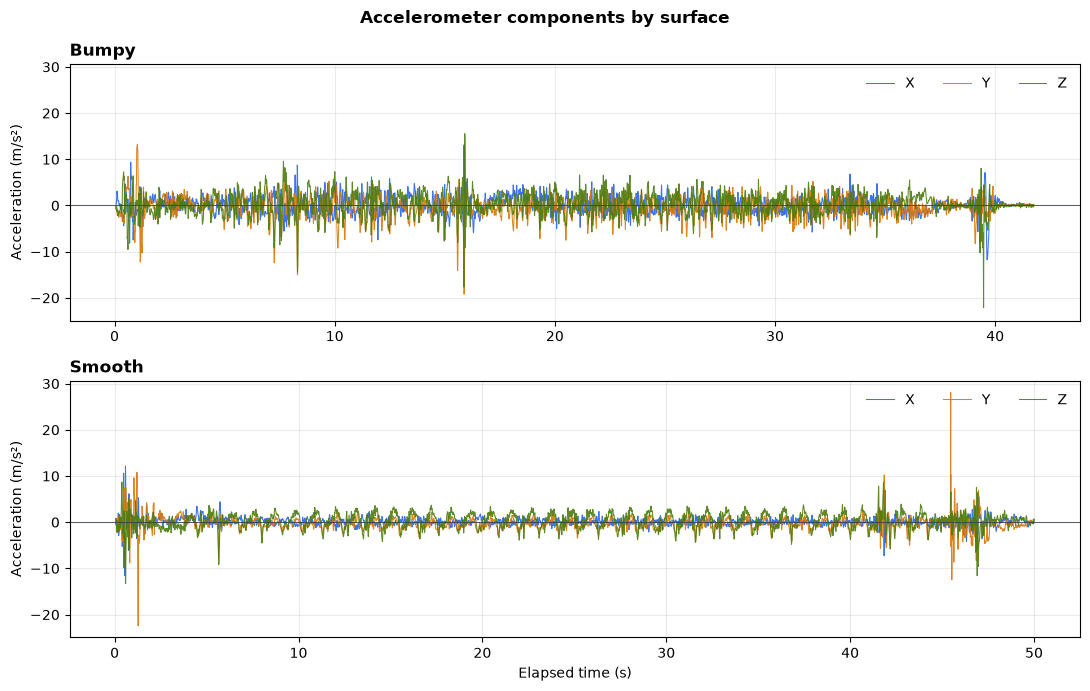

In [28]:
smooth_df = pd.read_csv(SMOOTH_RECORDING_PATH)

recordings = {
    "Bumpy": df,
    "Smooth": smooth_df,
}
axis_colors = {"x": "#2563EB", "y": "#D97706", "z": "#4D7C0F"}

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False, sharey=True)
for ax, (label, data) in zip(axes, recordings.items()):
    for component, color in axis_colors.items():
        ax.plot(
            data["seconds_elapsed"],
            data[component],
            label=component.upper(),
            color=color,
            linewidth=0.75,
            alpha=0.9,
        )
    ax.axhline(0, color="#374151", linewidth=0.6)
    ax.set_title(label, loc="left", fontweight="bold")
    ax.set_ylabel("Acceleration (m/s²)")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right", ncol=3, frameon=False)

axes[-1].set_xlabel("Elapsed time (s)")
fig.suptitle("Accelerometer components by surface", fontweight="bold")
fig.tight_layout()
plt.show()

The bumpy recording shows larger and more frequent deviations from zero across the three axes. The smooth recording is more concentrated around zero for most of its duration, although it still contains a few short, large peaks. This suggests that variation and peak-related features may help distinguish the classes, but the classes are not perfectly separated by every moment in the signal.

The comparison is descriptive only: the recordings have different durations and the peaks may also reflect phone movement. No filtering or peak removal is applied at this stage.

### Overall acceleration magnitude

The magnitude combines the three axes into one measure of total acceleration. It is useful for comparing overall movement intensity without focusing on the phone's orientation.

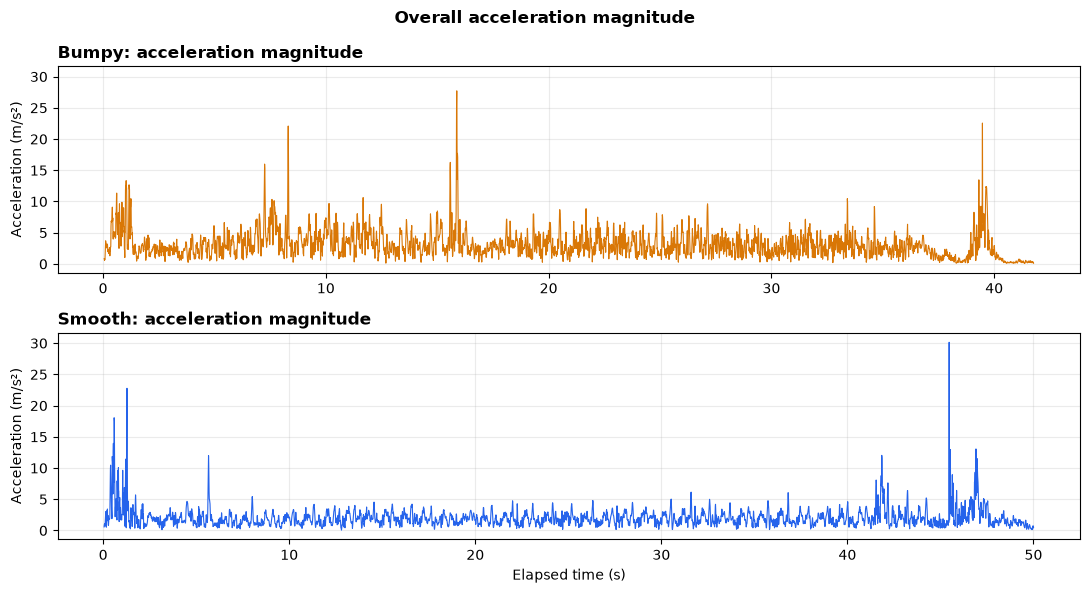

In [29]:
for data in recordings.values():
    data["magnitude"] = np.sqrt((data[["x", "y", "z"]] ** 2).sum(axis=1))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharey=True)
surface_colors = {"Bumpy": "#D97706", "Smooth": "#2563EB"}

for ax, (label, data) in zip(axes, recordings.items()):
    ax.plot(
        data["seconds_elapsed"],
        data["magnitude"],
        color=surface_colors[label],
        linewidth=0.8,
    )
    ax.set_title(f"{label}: acceleration magnitude", loc="left", fontweight="bold")
    ax.set_ylabel("Acceleration (m/s²)")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Elapsed time (s)")
fig.suptitle("Overall acceleration magnitude", fontweight="bold")
fig.tight_layout()
plt.show()

The magnitude plot makes the difference in overall movement easier to see: the bumpy recording shows more sustained variation, while the smooth recording stays closer to its baseline for most of the ride. Both recordings still contain isolated peaks, so magnitude alone will not perfectly separate the classes.